# Bayesian Optimization with AFL Pipelines

This tutorial shows an end-to-end Bayesian optimization campaign that stays native to the AFL pipeline API while using the BoTorch-backed `BoTorchRegressor` and `BoTorchAcquisition` ops.

Each optimization round runs the same AFL `Pipeline` on the current `xarray.Dataset`, reads the recommended next sample from the pipeline outputs, evaluates a BoTorch standard test function, and appends the new observation back into the dataset.

The notebook is written for low-dimensional synthetic objectives from `botorch.test_functions.synthetic`, such as `Branin`, `Ackley`, and `Hartmann`.

## 1. Set Up the Environment

Import the libraries used for the optimization campaign, configure plotting, and set a reproducible random seed.

In [1]:
# Uncomment this cell if you need to install AFL-agent with BoTorch support.
# !pip install -e .[botorch]

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from AFL.double_agent import (
    Pipeline,
    CartesianGrid,
    Standardize,
    BoTorchRegressor,
    BoTorchAcquisition,
)


plt.style.use("seaborn-v0_8-whitegrid")

rng = np.random.default_rng(7)
np.set_printoptions(precision=4, suppress=True)

In [3]:
# set campaign parameters
N_ITERATIONS = 10
N_INITIAL = 5
N_BATCH = 1

## 2. Define the Objective Function

BoTorch ships a collection of standard synthetic test functions. The helper below loads one by name, exposes its bounds, and evaluates it on NumPy arrays while preserving the original objective convention.

In [4]:
def load_test_function(name: str):
    from botorch.test_functions import synthetic
    if not hasattr(synthetic, name):
        available = sorted(
            candidate
            for candidate in dir(synthetic)
            if candidate and candidate[0].isupper()
        )

        raise ValueError(f"Unknown BoTorch synthetic function '{name}'. Try one of: {available[:20]}")

    function_cls = getattr(synthetic, name)
    test_function = function_cls(negate=False)
    bounds = test_function.bounds.detach().cpu().numpy().T
    dimension = bounds.shape[0]
    def evaluate(points: np.ndarray) -> np.ndarray:
        points = np.asarray(points, dtype=float)
        if points.ndim == 1:
            points = points[None, :]
        values = test_function(
            __import__("torch").as_tensor(points, dtype=__import__("torch").double)
        )
        return values.detach().cpu().numpy().reshape(-1)
    return test_function, bounds, dimension, evaluate

function_name = "Branin"
test_function, bounds, dimension, evaluate_objective = load_test_function(function_name)

if dimension == 1:
    grid_axis = np.linspace(bounds[0, 0], bounds[0, 1], 401)
    candidate_grid = grid_axis[:, None]
elif dimension == 2:
    axis_0 = np.linspace(bounds[0, 0], bounds[0, 1], 81)
    axis_1 = np.linspace(bounds[1, 0], bounds[1, 1], 81)
    mesh_0, mesh_1 = np.meshgrid(axis_0, axis_1, indexing="ij")
    candidate_grid = np.column_stack([mesh_0.ravel(), mesh_1.ravel()])
else:
    raise ValueError(
        f"This tutorial currently supports only 1D or 2D functions, but {function_name} has dimension {dimension}."
    )

initial_x = rng.uniform(bounds[:, 0], bounds[:, 1], size=(N_INITIAL, dimension))
initial_y = evaluate_objective(initial_x)
candidate_grid.shape, initial_x.shape
print(f"Objective function: {function_name} has bounds {bounds} \n"
      f"and global minimum value {test_function.optimal_value:.4f} at \n"
      f"{test_function.optimizers.cpu().numpy()}")

Objective function: Branin has bounds [[-5. 10.]
 [ 0. 15.]] 
and global minimum value 0.3979 at 
[[-3.1416 12.275 ]
 [ 3.1416  2.275 ]
 [ 9.4248  2.475 ]]


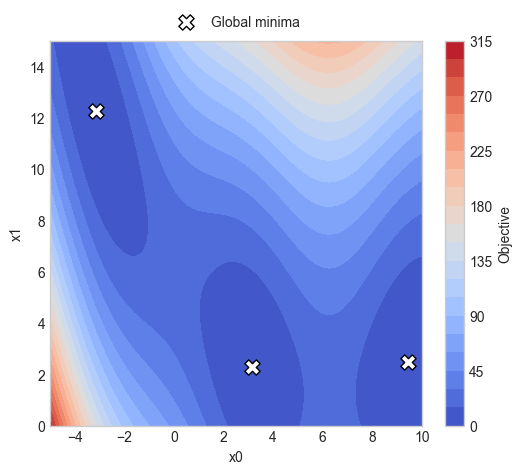

In [5]:
z_true = evaluate_objective(candidate_grid).reshape(mesh_0.shape)
global_minima = test_function.optimizers.cpu().numpy()

fig, ax = plt.subplots(figsize=(6, 5))

contour = ax.contourf(
    mesh_0,
    mesh_1,
    z_true,
    levels=20,
    cmap="coolwarm",
)

ax.scatter(
    global_minima[:, 0],
    global_minima[:, 1],
    c="white",
    edgecolors="black",
    marker="X",
    s=120,
    label="Global minima",
)

ax.set_xlabel("x0")
ax.set_ylabel("x1")
ax.legend(loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.10))

fig.colorbar(contour, ax=ax, label="Objective")
plt.show()

## 3. Specify the Search Space

Choose an initial design and build a dense candidate grid. This tutorial supports one- and two-dimensional BoTorch synthetic functions because the current AFL acquisition flow is grid-first.

In [6]:
from botorch.utils.sampling import draw_sobol_samples

if dimension > 2:
    raise ValueError(
        f"This tutorial currently supports only 1D or 2D functions, but {function_name} has dimension {dimension}."
    )

component_names = [f"x{i}" for i in range(dimension)]

sobol_bounds = __import__("torch").as_tensor(bounds.T, dtype=__import__("torch").double)
initial_x = (
    draw_sobol_samples(bounds=sobol_bounds, n=1, q=N_INITIAL, seed=0)
    .squeeze(0)
    .detach()
    .cpu()
    .numpy()
)
initial_y = evaluate_objective(initial_x)

print(f"Initial samples:\n{pd.DataFrame(initial_x, columns=component_names).assign(objective=initial_y)}")

Initial samples:
         x0         x1   objective
0  2.126608   8.887860   37.289563
1  2.417188   4.707776    6.049219
2  9.341378   1.249534    1.767633
3 -3.518548   5.211992   64.868666
4  7.703730  11.422624  111.771974


In [7]:
component_names = [f"x{i}" for i in range(dimension)]

initial_dataset = xr.Dataset(
    data_vars={
        "composition": (("sample", "component"), initial_x),
        "objective": ("sample", initial_y),
    },
    coords={"component": component_names},
)
initial_dataset

<xarray.Dataset> Size: 136B
Dimensions:      (sample: 5, component: 2)
Coordinates:
  * component    (component) <U2 16B 'x0' 'x1'
Dimensions without coordinates: sample
Data variables:
    composition  (sample, component) float64 80B 2.127 8.888 ... 7.704 11.42
    objective    (sample) float64 40B 37.29 6.049 1.768 64.87 111.8

## 4. Run Bayesian Optimization

Define a reusable AFL pipeline and execute it repeatedly. The pipeline itself stays fixed; only the dataset grows as new observations are appended.

In [8]:
grid_spec = {
    name: {"min": float(lo), "max": float(hi), "steps": 20}
    for name, (lo, hi) in zip(component_names, bounds.tolist())
}

with Pipeline() as bayesopt_pipeline:
    CartesianGrid(
        output_variable="composition_grid_raw",
        grid_spec=grid_spec,
        sample_dim="grid",
        component_dim="component",
    )

    Standardize(
        input_variable="composition",
        output_variable="composition_std",
        dim="grid",
        component_dim="component",
        scale_variable="composition_grid_raw",
    )

    Standardize(
        input_variable="composition_grid_raw",
        output_variable="composition_grid",
        dim="grid",
        component_dim="component",
    )

    BoTorchRegressor(
        feature_input_variable="composition_std",
        predictor_input_variable="objective",
        grid_variable="composition_grid",
        grid_dim="grid",
        sample_dim="sample",
        output_prefix="botorch",
        objective_direction="minimize",
        posterior_optimize=True,
    )

    BoTorchAcquisition(
        feature_input_variable="composition_std",
        predictor_input_variable="objective",
        grid_variable="composition_grid",
        grid_dim="grid",
        sample_dim="sample",
        objective_direction="minimize",
        acquisition_kind="qlogei",
        best_f_variable="botorch_best_f",
        output_prefix="botorch",
        decision_rtol=1.0,
        count=N_BATCH,
    )

In [9]:
history = []

for x_row, y_val in zip(initial_x, initial_y):
    history.append(
        {
            "iteration": 0,
            "suggested_x": x_row.tolist(),
            "objective": float(y_val),
            "best_observed": float(np.min(initial_y)),
            "best_posterior": np.nan,
            "best_posterior_location": None,
        }
    )

campaign_dataset = initial_dataset.copy()

for iteration in range(N_ITERATIONS):
    result = bayesopt_pipeline.calculate(campaign_dataset, disable_progress_bar=True)

    suggested_x = np.asarray(result["next_samples"].values, dtype=float).reshape(N_BATCH, dimension)
    suggested_y = evaluate_objective(suggested_x)

    best_observed = float(np.min(campaign_dataset["objective"].values))
    best_posterior = float(np.asarray(result["botorch_best_f"].values).reshape(-1)[0])
    best_posterior_location = np.asarray(
        result["botorch_best_x"].values, dtype=float
    ).reshape(-1).tolist()

    for batch_member, (x_row, y_val) in enumerate(zip(suggested_x, suggested_y)):
        history.append(
            {
                "iteration": iteration+1,
                "suggested_x": x_row.tolist(),
                "objective": float(y_val),
                "best_observed": best_observed,
                "best_posterior": best_posterior,
                "best_posterior_location": best_posterior_location,
            }
        )

    updated_x = np.vstack([campaign_dataset["composition"].values, suggested_x])
    updated_y = np.concatenate([campaign_dataset["objective"].values, suggested_y])

    campaign_dataset = xr.Dataset(
        data_vars={
            "composition": (("sample", "component"), updated_x),
            "objective": ("sample", updated_y),
        },
        coords={
            "sample": np.arange(updated_x.shape[0]),
            "component": component_names,
        },
    )

history_df = pd.DataFrame(history).set_index("iteration")
history_df

,suggested_x,objective,best_observed,best_posterior,best_posterior_location
iteration,,,,,
0,"[2.1266077551990747, 8.887859727256]",37.289563,1.767633,NaN,None
0,"[2.4171879841014743, 4.707775977440178]",6.049219,1.767633,NaN,None
0,"[9.341377750970423, 1.2495335564017296]",1.767633,1.767633,NaN,None
0,"[-3.518547718413174, 5.211991709657013]",64.868666,1.767633,NaN,None
0,"[7.703730380162597, 11.422624387778342]",111.771974,1.767633,NaN,None
1,"[0.7063676786115726, 0.10601830611992093]",40.674245,1.767633,0.087429,"[0.8414478607087343, 0.09716918714135396]"
2,"[0.7271571753512608, 0.14487502597293678]",39.889377,1.767633,-0.243806,"[0.8312134353054518, 0.10864019208141946]"
3,"[0.7291749835590083, 0.1478321624171413]",39.821335,1.767633,0.879403,"[0.8903637855593641, 0.08878086226650754]"
4,"[0.7322323886309159, 0.14824675488150138]",39.756984,1.767633,1.308807,"[0.9147119353555778, 0.08310338090085889]"


## 5. Inspect Best Parameters and Best Score

The objective values below are reported in the original BoTorch test-function convention, so lower is better for the standard minimization problems used here.

In [10]:
best_x = result["botorch_best_x"].values
best_y = float(result["botorch_best_f"].values)
print(f"Function: {function_name}")
print(f"Best objective: {best_y:.6f}")
print("Best parameters:", best_x)

Function: Branin
Best objective: 1.627841
Best parameters: [0.956  0.0644]


## 6. Visualize Optimization Progress

Plot the best-so-far trace across iterations. For one-dimensional objectives, also compare the sampled points against the true objective and the final acquisition surface.

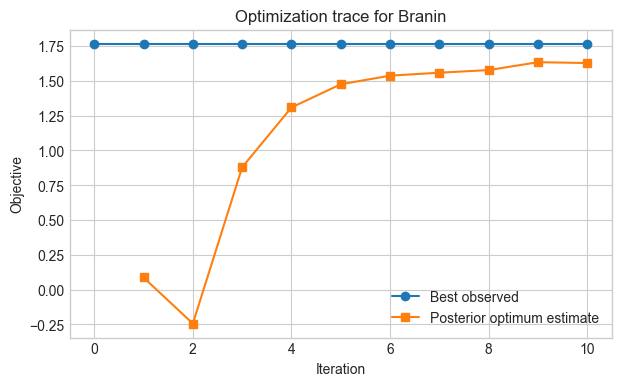

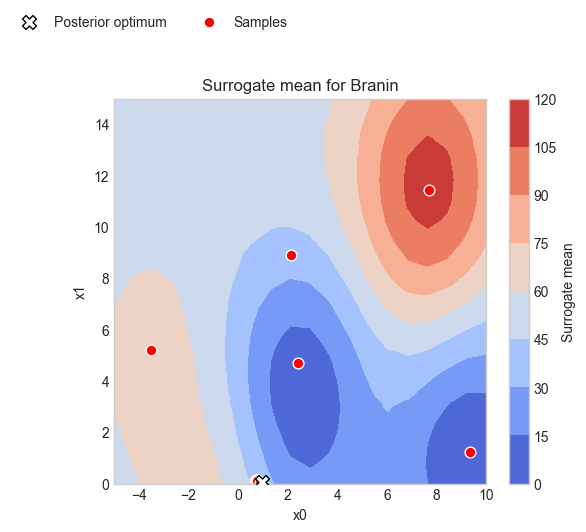

In [11]:
history_by_iteration = history_df.groupby(level=0).first().copy()
history_by_iteration["best_so_far"] = history_by_iteration["best_observed"].cummin()

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(
    history_by_iteration.index,
    history_by_iteration["best_so_far"],
    marker="o",
    label="Best observed",
)
ax.plot(
    history_by_iteration.index,
    history_by_iteration["best_posterior"],
    marker="s",
    label="Posterior optimum estimate",
)
ax.set_xlabel("Iteration")
ax.set_ylabel("Objective")
ax.set_title(f"Optimization trace for {function_name}")
ax.legend()
plt.show()

final_result = bayesopt_pipeline.calculate(campaign_dataset, disable_progress_bar=True)

if dimension == 1:
    grid_x = np.asarray(final_result["composition_grid_raw"].values, dtype=float)
    surrogate_mean = np.asarray(final_result["botorch_mean"].values, dtype=float)
    surrogate_var = np.asarray(final_result["botorch_variance"].values, dtype=float)
    acquisition = np.asarray(final_result["botorch_decision_surface"].values, dtype=float)

    x_plot = grid_x[:, 0]
    order = np.argsort(x_plot)

    fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharex=True)

    axes[0].plot(
        x_plot[order],
        evaluate_objective(grid_x)[order],
        label="True objective",
        color="black",
    )
    axes[0].scatter(
        campaign_dataset["composition"].values[:, 0],
        campaign_dataset["objective"].values,
        color="tab:red",
        label="Samples",
    )
    axes[0].set_ylabel("Objective")
    axes[0].legend()

    axes[1].plot(
        x_plot[order],
        surrogate_mean[order],
        color="tab:blue",
        label="Surrogate mean",
    )
    axes[1].fill_between(
        x_plot[order],
        surrogate_mean[order] - 2.0 * np.sqrt(surrogate_var[order]),
        surrogate_mean[order] + 2.0 * np.sqrt(surrogate_var[order]),
        color="tab:blue",
        alpha=0.2,
        label="Mean +/- 2 sigma",
    )
    axes[1].set_ylabel("Surrogate")
    axes[1].legend()

    axes[2].plot(
        x_plot[order],
        acquisition[order],
        color="tab:green",
        label="Acquisition",
    )
    axes[2].set_xlabel("x")
    axes[2].set_ylabel("Decision surface")
    axes[2].legend()

    plt.show()

elif dimension == 2:
    grid_x = np.asarray(final_result["composition_grid_raw"].values, dtype=float)
    surrogate_mean = np.asarray(final_result["botorch_mean"].values, dtype=float)

    fig, ax = plt.subplots(figsize=(6, 5))
    sc = ax.tricontourf(
        grid_x[:, 0],
        grid_x[:, 1],
        surrogate_mean,
        cmap="coolwarm",
    )
    ax.scatter(
        final_result["botorch_best_x"].values[0],
        final_result["botorch_best_x"].values[1],
        color="white",
        edgecolor="black",
        marker="X",
        s=100,
        label="Posterior optimum",
        zorder=5,
    )
    ax.scatter(
        campaign_dataset["composition"].values[:, 0],
        campaign_dataset["composition"].values[:, 1],
        color="red",
        edgecolor="white",
        s=60,
        label="Samples",
    )
    ax.set_xlabel("x0")
    ax.set_ylabel("x1")
    ax.set_title(f"Surrogate mean for {function_name}")
    ax.legend(loc="upper right", ncol=2, bbox_to_anchor=(0.5, 1.25))
    fig.colorbar(sc, ax=ax, label="Surrogate mean")
    plt.show()

## 7. Compare Suggested Configurations

Create a compact table of all evaluated points, sorted by objective value.

In [12]:
results_df = pd.DataFrame(
    campaign_dataset["composition"].values,
    columns=[str(feature) for feature in campaign_dataset.coords["component"].values],
)

results_df["objective"] = campaign_dataset["objective"].values
results_df = results_df.sort_values("objective", ascending=True).reset_index(drop=True)
results_df

,x0,x1,objective
0,9.341378,1.249534,1.767633
1,2.417188,4.707776,6.049219
2,2.126608,8.887860,37.289563
3,0.873225,0.007312,38.271271
4,0.771559,0.101214,39.423838
5,0.739864,0.140901,39.675945
6,0.742352,0.134035,39.691980
7,0.736352,0.145820,39.698644
8,0.732232,0.148247,39.756984
9,0.743102,0.125440,39.758941
